# 1. Importing Libraries

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 2. Read Dataset

In [165]:
data = pd.read_csv(r"titanic.csv")

### Basic information and description

In [166]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [167]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [168]:
data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

we see that we have `819 record` and `12 features`
we also see that we have **687** null value in `Cabin` and only **2** null values in `Embarked` and **177** in `Age`

# 2. EDA – Exploratory data analysis

In [169]:
# check for duplicate
data.duplicated().sum()

np.int64(0)

In [170]:
# the taget is "survived column"
data["y"] = data["Survived"]
data.drop(columns="Survived",inplace=True)

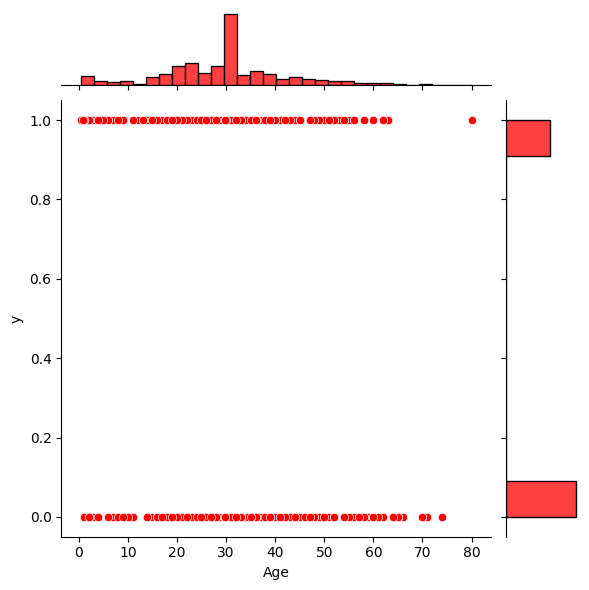

In [188]:
plt.style.use('default')
sns.jointplot(data=data , x="Age", y="y", color="r")

C:\Users\LOQ\AppData\Local\Temp\ipykernel_9764\941592782.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Age'], bins = 20, kde=True, hist_kws=dict(edgecolor="k", linewidth=1))


<Axes: xlabel='Age', ylabel='Density'>

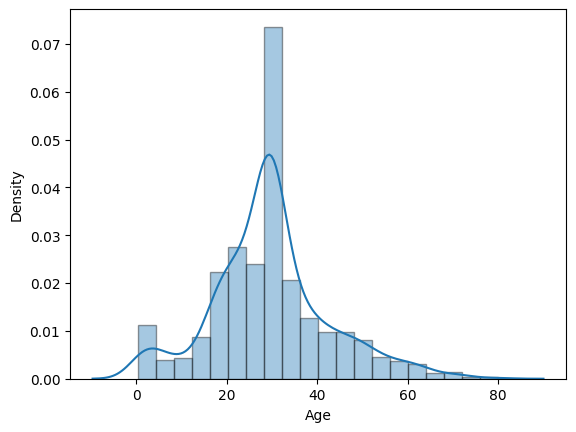

In [189]:
sns.distplot(data['Age'], bins = 20, kde=True, hist_kws=dict(edgecolor="k", linewidth=1))

### Drop useless features

In [172]:
data.drop(columns="Ticket",inplace=True)
data.drop(columns="Cabin",inplace=True)
data.drop(columns="PassengerId",inplace=True)

### fill nan for useful features

In [173]:
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])
data["Age"] = data["Age"].fillna(data["Age"].mean())

### features extraction & features engineering

In [174]:
data["Title"] = data["Name"].str.split(",").str[1].str.split(".").str[0].str.strip()
data.drop(columns="Name",inplace=True)

data["familySize"] = data["SibSp"] + data["Parch"]

In [175]:
data['y'].value_counts(normalize=True)

y
0    0.616162
1    0.383838
Name: proportion, dtype: float64

`61%` not survived , and `38%` survived

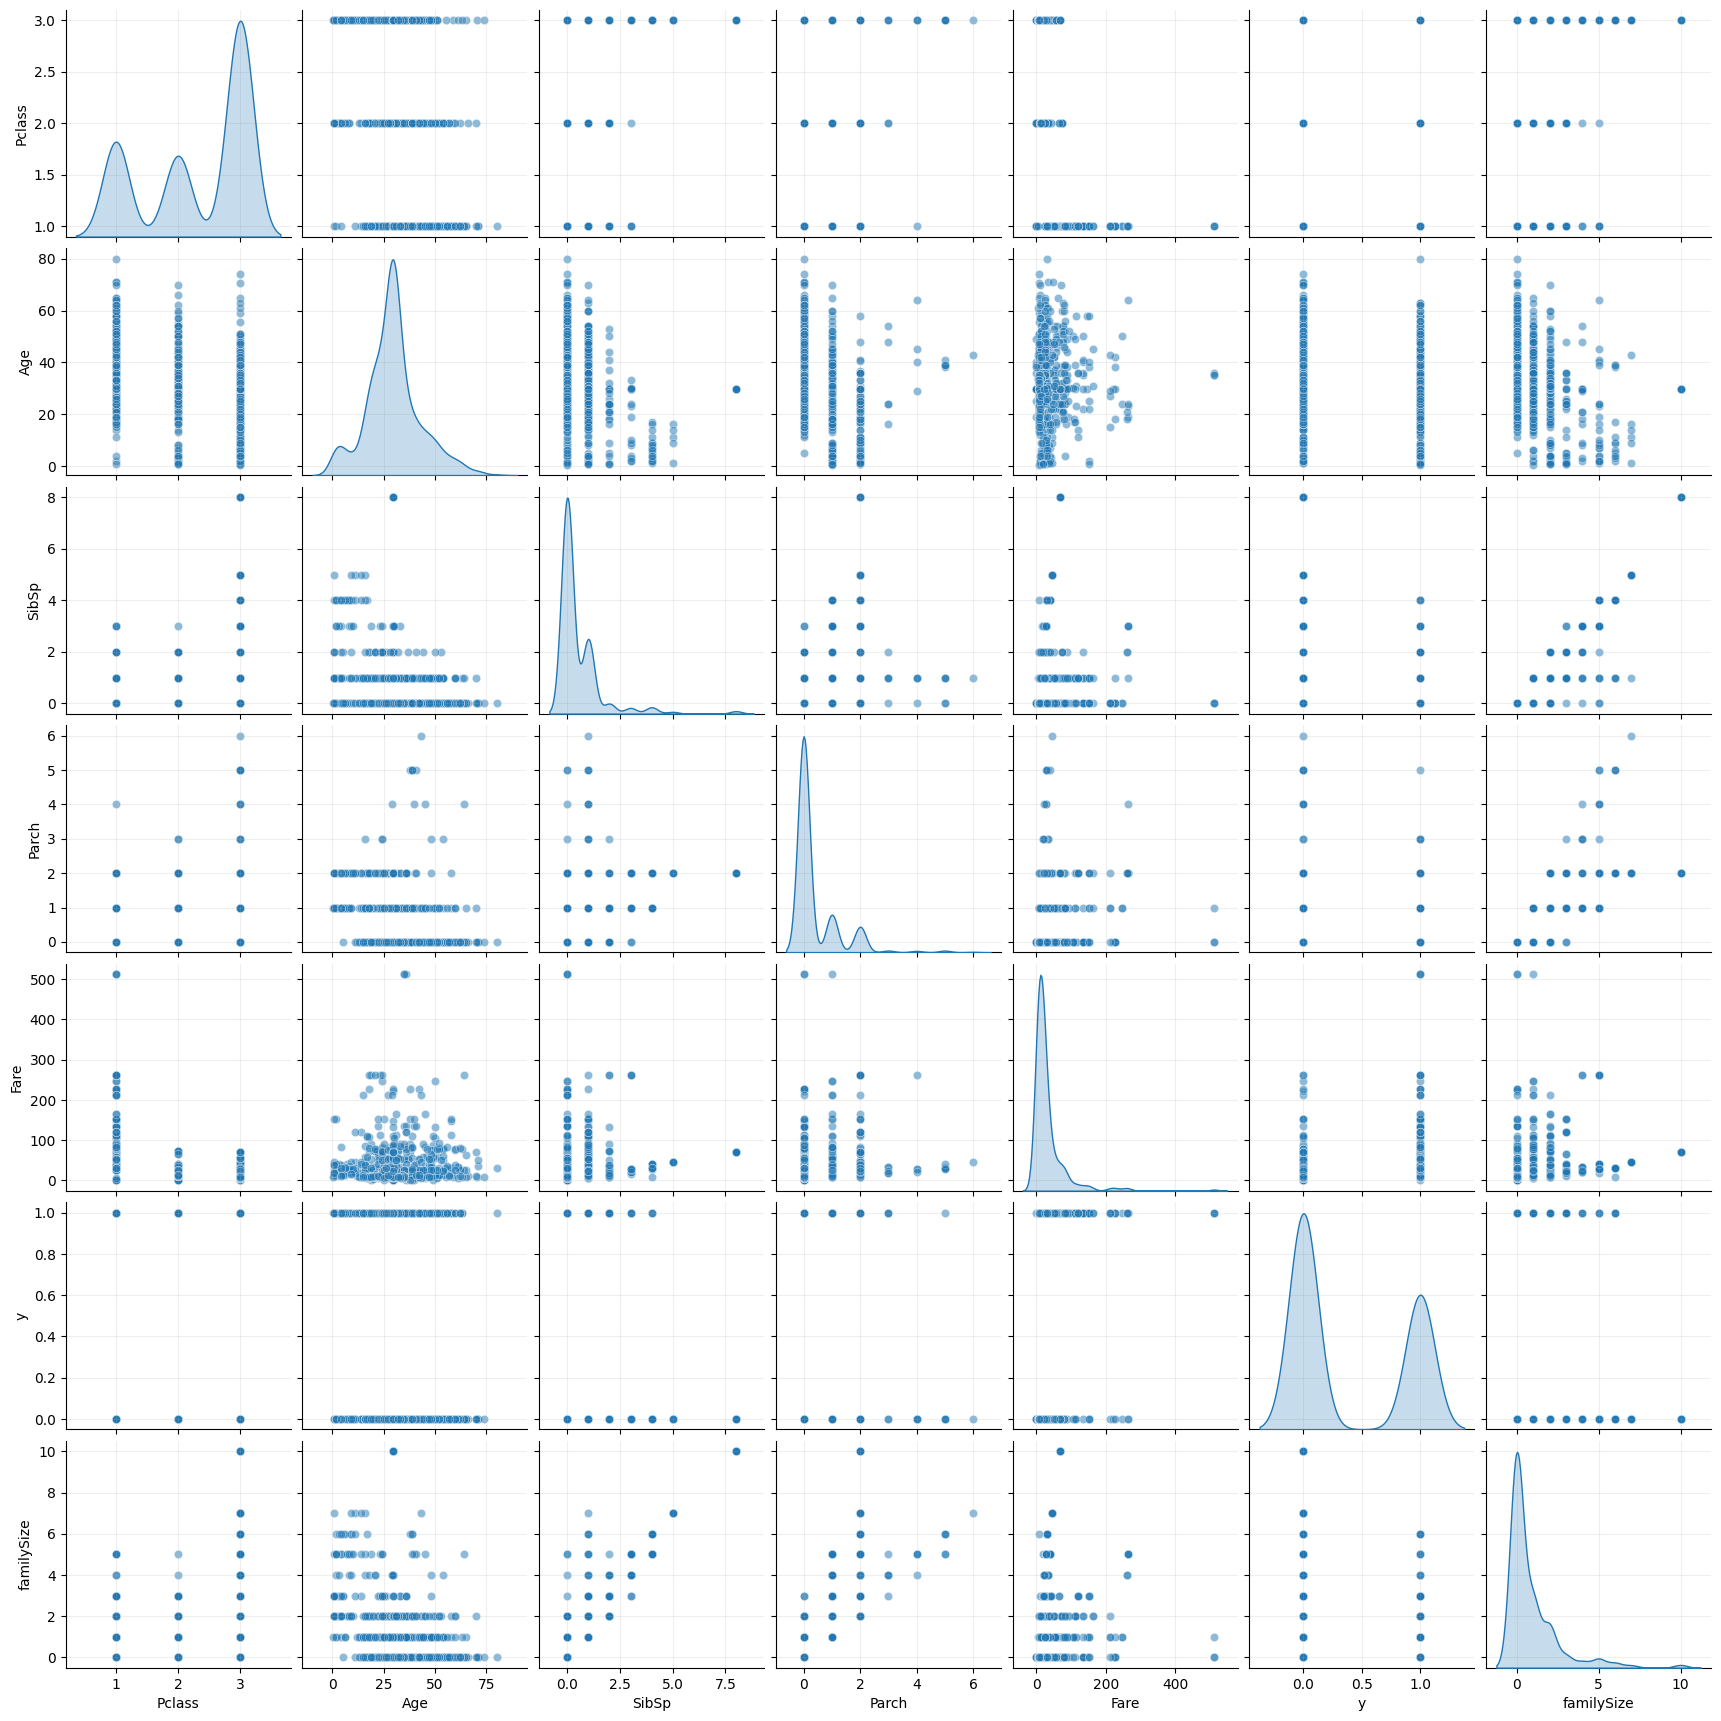

In [176]:
g = sns.pairplot(
    data=data,
    diag_kind="kde",
    plot_kws={"alpha": 0.5}
)

# Change grid transparency
for ax in g.axes.flatten():
    if ax is not None:
        ax.grid(True, alpha=0.2)  # Change alpha here

plt.show()

In [177]:
corr = data.corr(numeric_only=True)
corr['y'].sort_values(ascending=False)
abs(corr['y']).sort_values(ascending=False)

y             1.000000
Pclass        0.338481
Fare          0.257307
Parch         0.081629
Age           0.069809
SibSp         0.035322
familySize    0.016639
Name: y, dtype: float64

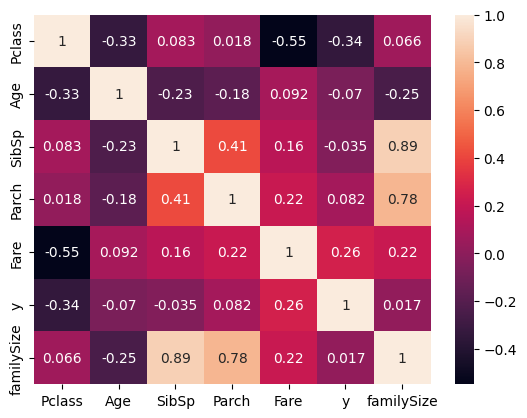

In [178]:
sns.heatmap(corr, annot=True)
plt.show()

In [179]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      891 non-null    int64  
 1   Sex         891 non-null    object 
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Embarked    891 non-null    object 
 7   y           891 non-null    int64  
 8   Title       891 non-null    object 
 9   familySize  891 non-null    int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 69.7+ KB


In [180]:
data

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,y,Title,familySize
0,3,male,22.000000,1,0,7.2500,S,0,Mr,1
1,1,female,38.000000,1,0,71.2833,C,1,Mrs,1
2,3,female,26.000000,0,0,7.9250,S,1,Miss,0
3,1,female,35.000000,1,0,53.1000,S,1,Mrs,1
4,3,male,35.000000,0,0,8.0500,S,0,Mr,0
...,...,...,...,...,...,...,...,...,...,...
886,2,male,27.000000,0,0,13.0000,S,0,Rev,0
887,1,female,19.000000,0,0,30.0000,S,1,Miss,0
888,3,female,29.699118,1,2,23.4500,S,0,Miss,3
889,1,male,26.000000,0,0,30.0000,C,1,Mr,0


In [181]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Sex','Embarked','Title']
for col in categorical_cols:
    data[col] = LabelEncoder().fit_transform(data[col])

In [182]:
data

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,y,Title,familySize
0,3,1,22.000000,1,0,7.2500,2,0,11,1
1,1,0,38.000000,1,0,71.2833,0,1,12,1
2,3,0,26.000000,0,0,7.9250,2,1,8,0
3,1,0,35.000000,1,0,53.1000,2,1,12,1
4,3,1,35.000000,0,0,8.0500,2,0,11,0
...,...,...,...,...,...,...,...,...,...,...
886,2,1,27.000000,0,0,13.0000,2,0,14,0
887,1,0,19.000000,0,0,30.0000,2,1,8,0
888,3,0,29.699118,1,2,23.4500,2,0,8,3
889,1,1,26.000000,0,0,30.0000,0,1,11,0


In [138]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = data.drop(['y'], axis=1)
y = data['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [183]:
X_train_scaled

array([[-1.61413602,  0.7243102 ,  1.22920747, ...,  0.5635246 ,
         0.41635477, -0.55466613],
       [-0.40055118,  0.7243102 , -0.50350514, ...,  0.5635246 ,
         0.41635477, -0.55466613],
       [ 0.81303367,  0.7243102 ,  0.18957991, ...,  0.5635246 ,
         0.41635477, -0.55466613],
       ...,
       [ 0.81303367,  0.7243102 ,  0.88266495, ...,  0.5635246 ,
         0.41635477,  0.63485883],
       [-1.61413602, -1.38062393, -1.19659018, ...,  0.5635246 ,
        -1.24595137,  1.22962131],
       [-1.61413602,  0.7243102 , -0.65752403, ...,  0.5635246 ,
         0.41635477,  0.04009635]], shape=(712, 9))

In [184]:
X_test_scaled

array([[ 0.81303367,  0.7243102 ,  0.01239022, ..., -2.02505292,
        -1.80005342,  0.63485883],
       [-0.40055118,  0.7243102 ,  0.11257046, ...,  0.5635246 ,
         0.41635477, -0.55466613],
       [ 0.81303367,  0.7243102 , -0.73453348, ...,  0.5635246 ,
         0.41635477, -0.55466613],
       ...,
       [ 0.81303367, -1.38062393,  0.6516366 , ...,  0.5635246 ,
         0.97045681,  3.01390875],
       [-0.40055118, -1.38062393, -0.96556183, ...,  0.5635246 ,
        -1.24595137, -0.55466613],
       [ 0.81303367, -1.38062393, -1.96668467, ...,  0.5635246 ,
        -1.24595137,  0.63485883]], shape=(179, 9))